In [14]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
from scipy.integrate import odeint
import scipy

In [9]:
def toggle_switch(yz, t, beta_y, beta_z, gamma, n_x, n_y, x):
    """
    Right hand side for cascade X -> Y -> Z.  Return dy/dt and dz/dt.
    """
    # Unpack y and z
    y, z = yz
    
    # Compute dy/dt
    dy_dt = beta_y * x**n_x / (1 + x**n_x) - y
    
    # Compute dz/dt
    dz_dt = gamma * (beta_z * y**n_y / (1 + y**n_y) - z)
    
    # Return the result as a NumPy array
    return np.array([dy_dt, dz_dt])

In [61]:
def general_toggle_switch(yz, t, *args):
    """
    Right hand side for cascade X -> Y -> Z.  Return dy/dt and dz/dt.
    """
    args = (np.array(args).reshape(2, 7))
    args1 = args[0]
    args2 = args[1]
    
    # Unpack y and z
    y, z = yz
    
    # Compute dy/dt
    dy_dt = generalized_hill_function(yz, args1) - args1[6]*y
    
    # Compute dz/dt
    dz_dt = generalized_hill_function(yz, args2) - args2[6]*z
    
    # Return the result as a NumPy array
    return np.array([dy_dt, dz_dt])

In [52]:
def generalized_hill_function(y, args):
    a1    = args[0]
    a2    = args[1]
    b1    = args[2]
    b2    = args[3]
    n1    = args[4]
    n2    = args[5]
    x1, x2= y
    return (1 + a1*x1**n1 + a2*x2**n2)/(1 + b1*x1**n1 + b2*x2**n2)

In [53]:
def residuals(p):
    p = tuple(p)
    sim_P = odeint(general_toggle_switch, iv, t, args = p).T
    #print(sim_P)
    res = sim_P - exp_P
    return res.flatten()

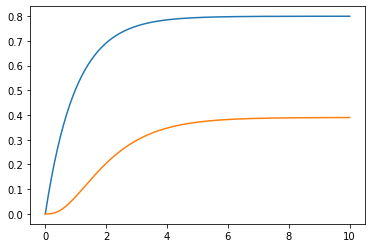

In [54]:
# Number of time points we want for the solutions
n = 400

# Time points we want for the solution
t = np.linspace(0, 10, n)

# Initial condition
iv = yz_0 = np.array([0.0, 0.0])

# Parameters
beta_y = 1.0
beta_z = 1.0
gamma = 1.0
n_x = 2
n_y = 2
x_0 = 2.0

# Package parameters into a tuple
args = (beta_y, beta_z, gamma, n_x, n_y, x_0)

# Integrate ODES
yz_og = scipy.integrate.odeint(toggle_switch, yz_0, t, args=args).T

y_og, z_og = yz_og[0], yz_og[1]

plt.plot(t, y_og)
plt.plot(t, z_og)

In [55]:
exp_P = yz_og# + np.random.randn(len(yz_og))*0.5
exp_P = exp_P#[::5]

In [56]:
fitted_params

array([ 1.57319699e+00,  4.21375910e+00,  3.60886106e+00, -6.91579689e-01,
        5.68753514e+00,  3.95064214e+00,  5.36083868e-01,  9.01461812e-02,
        3.54450083e+00,  1.62511725e+00,  7.00704840e-06,  9.24742843e+00])

In [62]:
initial_guess = [1, 2, 5, 3, 1, 2, 5, 3, 1, 1, 4, 1, 2, 1]
fitted_params = leastsq(residuals, initial_guess)[0]

/Users/dennisjoshy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  if __name__ == '__main__':
/Users/dennisjoshy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in double_scalars
  if __name__ == '__main__':
/Users/dennisjoshy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: overflow encountered in double_scalars
  if __name__ == '__main__':
/Users/dennisjoshy/anaconda3/lib/python3.7/site-packages/scipy/integrate/odepack.py:247: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


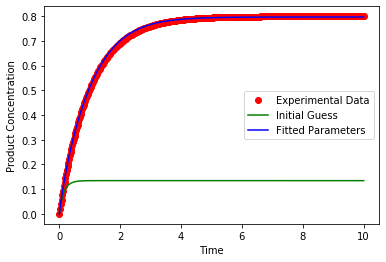

In [63]:
plt.plot(t, exp_P[0], 'ro')
plt.plot(t, odeint(general_toggle_switch, iv, t, args = tuple(initial_guess)).T[0], 'g-')
plt.plot(t, odeint(general_toggle_switch, iv, t, args = tuple(fitted_params)).T[0], 'b-')
plt.legend(['Experimental Data', 'Initial Guess', 'Fitted Parameters'], loc = 'best')
plt.xlabel('Time')
plt.ylabel('Product Concentration')
plt.show()

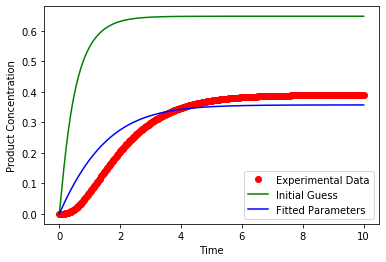

In [64]:
plt.plot(t, exp_P[1], 'ro')
plt.plot(t, odeint(general_toggle_switch, iv, t, args = tuple(initial_guess)).T[1], 'g-')
plt.plot(t, odeint(general_toggle_switch, iv, t, args = tuple(fitted_params)).T[1], 'b-')
plt.legend(['Experimental Data', 'Initial Guess', 'Fitted Parameters'], loc = 'best')
plt.xlabel('Time')
plt.ylabel('Product Concentration')
plt.show()

In [65]:
fitted_params

array([4.42984378e+00, 2.64633393e+00, 6.09839875e-01, 2.04067107e+00,
       1.47508897e+00, 3.92408011e+01, 3.64248900e+00, 2.00547460e+00,
       3.55618811e-01, 2.74067797e+00, 4.89388310e+00, 1.30427255e+00,
       3.65203946e-08, 1.00450648e+00])